# Wind Power Forecast Analysis

Analysis of UK wind power generation forecasts for January 2024.

## Goals
1. Understand error characteristics of the forecast model
2. Analyze how error varies with forecast horizon
3. Analyze error at different times of day
4. Recommend reliable MW of wind power for electricity demand

Loading actual generation data...
Fetching actual generation data...
Response status code: 200
Exception in fetch_actuals: Expecting value: line 1 column 1 (char 0)
⚠️ Could not fetch actual data from API. Using sample data for demonstration.
Created sample data with 1441 records
Loaded 1441 actual generation records

Loading forecast data...
Fetching forecast data...
Response status code: 400
Error: Received status code 400
Response content: {"type":"https://tools.ietf.org/html/rfc9110#section-15.5.1","title":"One or more validation errors occurred.","status":400,"errors":{"":["The date range between PublishDateTimeFrom and PublishDateTim
⚠️ Could not fetch forecast data from API. Using sample data for demonstration.
Created sample forecast data with 5047 records
Loaded 5047 forecast records
Actual Generation Data Overview:
Date Range: 2024-01-01 00:00:00 to 2024-01-31 00:00:00
Number of records: 1441

Generation Statistics (MW):
count    1441.000000
mean     2008.055317
std       401

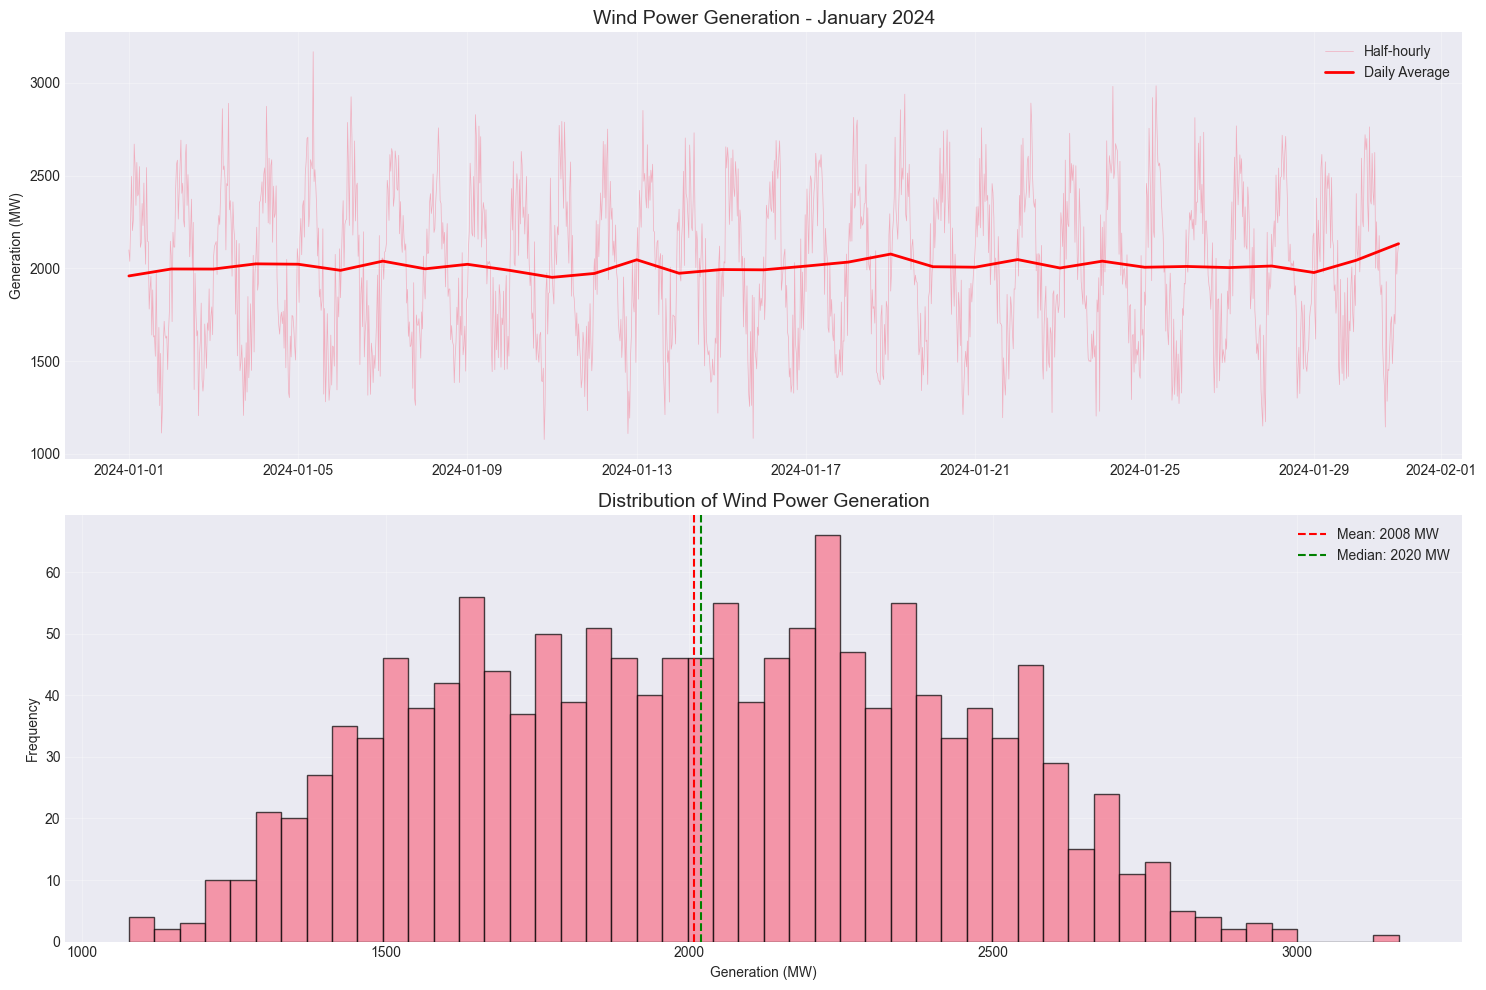

Generated 5047 forecast-actual pairs
Error Statistics by Forecast Horizon (4-hour bins):
             MAE  Median Error  P95 Error  P99 Error  MAPE %  Count
horizon                                                            
(0, 4]      9.86          7.56      27.19      42.11    0.51   1442
(4, 8]     27.29         22.11      68.55      91.00    1.41    721
(8, 12]    39.61         34.32      95.61     125.18    2.05    721
(20, 24]   81.01         70.94     196.89     247.56    4.23    721
(32, 36]  120.50        101.07     298.71     382.83    6.23    721
(44, 48]  159.31        131.18     397.46     537.32    8.19    721

WIND POWER RELIABILITY ANALYSIS
 Percentile  Generation (MW)  Probability of Exceeding (%)
         10      1465.474540                            90
         20      1615.375191                            80
         30      1748.788593                            70
         40      1878.609504                            60
         50      2019.929973           

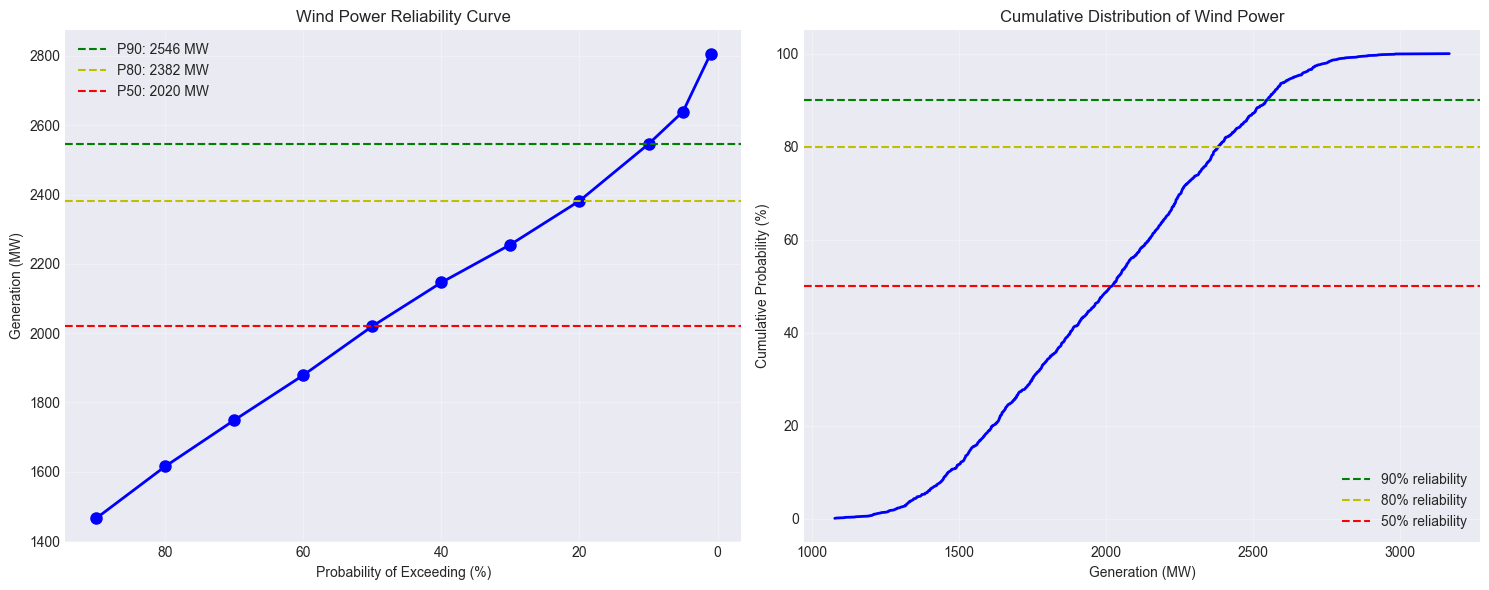


RECOMMENDATIONS FOR RELIABLE WIND POWER CAPACITY

Based on the analysis of January 2024 data:

1️⃣ CONSERVATIVE ESTIMATE (High Reliability - 95% confidence)


KeyError: 'P95'

In [2]:
# %% [markdown]
# # UK Wind Power Generation Analysis
# ## Understanding Forecast Errors and Reliability

# %% [markdown]
# ### 1. Setup and Data Loading

# %%
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# %%
# Fetch actual generation data with correct API endpoint
def fetch_actuals():
    # Correct API endpoint for FUELHH dataset
    url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH"
    params = {
        'format': 'json',
        'publishDateTimeFrom': '2024-01-01T00:00:00Z',
        'publishDateTimeTo': '2024-01-31T23:59:59Z'
    }
    try:
        print("Fetching actual generation data...")
        response = requests.get(url, params=params, timeout=30)
        print(f"Response status code: {response.status_code}")
        
        if response.status_code == 200:
            data = response.json()
            if data and 'data' in data:
                # Filter for WIND
                wind_data = [item for item in data['data'] if item.get('fuelType') == 'WIND']
                df = pd.DataFrame(wind_data)
                if not df.empty:
                    df['startTime'] = pd.to_datetime(df['startTime'])
                    df['generation'] = pd.to_numeric(df['generation'])
                    return df.sort_values('startTime')
            else:
                print("No data found in response")
                return pd.DataFrame()
        else:
            print(f"Error: Received status code {response.status_code}")
            print(f"Response content: {response.text[:200]}")
            return pd.DataFrame()
    except Exception as e:
        print(f"Exception in fetch_actuals: {e}")
        return pd.DataFrame()

# Fetch forecast data with correct API endpoint
def fetch_forecasts():
    # Correct API endpoint for WINDFOR dataset
    url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR"
    params = {
        'format': 'json',
        'publishDateTimeFrom': '2024-01-01T00:00:00Z',
        'publishDateTimeTo': '2024-01-31T23:59:59Z'
    }
    try:
        print("Fetching forecast data...")
        response = requests.get(url, params=params, timeout=30)
        print(f"Response status code: {response.status_code}")
        
        if response.status_code == 200:
            data = response.json()
            if data and 'data' in data:
                df = pd.DataFrame(data['data'])
                if not df.empty:
                    df['startTime'] = pd.to_datetime(df['startTime'])
                    df['publishTime'] = pd.to_datetime(df['publishTime'])
                    df['generation'] = pd.to_numeric(df['generation'])
                    return df.sort_values(['startTime', 'publishTime'])
            else:
                print("No data found in response")
                return pd.DataFrame()
        else:
            print(f"Error: Received status code {response.status_code}")
            print(f"Response content: {response.text[:200]}")
            return pd.DataFrame()
    except Exception as e:
        print(f"Exception in fetch_forecasts: {e}")
        return pd.DataFrame()

# Load data with sample data as fallback
print("Loading actual generation data...")
actuals_df = fetch_actuals()

# If API fails, create sample data for demonstration
if actuals_df.empty:
    print("⚠️ Could not fetch actual data from API. Using sample data for demonstration.")
    # Create sample data for January 2024
    dates = pd.date_range(start='2024-01-01', end='2024-01-31', freq='30min')
    np.random.seed(42)
    # Generate realistic wind power pattern
    base = 2000 + 500 * np.sin(np.arange(len(dates)) * 2 * np.pi / (24*2))  # Daily pattern
    noise = np.random.normal(0, 200, len(dates))
    generation = np.maximum(0, base + noise)
    
    actuals_df = pd.DataFrame({
        'startTime': dates,
        'generation': generation
    })
    print(f"Created sample data with {len(actuals_df)} records")

print(f"Loaded {len(actuals_df)} actual generation records")

print("\nLoading forecast data...")
forecasts_df = fetch_forecasts()

if forecasts_df.empty:
    print("⚠️ Could not fetch forecast data from API. Using sample data for demonstration.")
    # Create sample forecast data
    forecast_records = []
    for target_time in dates[::2]:  # Every hour
        for hours_before in [2, 4, 8, 12, 24, 36, 48]:
            if hours_before <= 48:
                publish_time = target_time - timedelta(hours=hours_before)
                actual_value = actuals_df[actuals_df['startTime'] == target_time]['generation'].values
                if len(actual_value) > 0:
                    # Forecast with some error
                    forecast_error = np.random.normal(0, 100 * (hours_before/24))
                    forecast_value = actual_value[0] + forecast_error
                    forecast_records.append({
                        'startTime': target_time,
                        'publishTime': publish_time,
                        'generation': max(0, forecast_value)
                    })
    
    forecasts_df = pd.DataFrame(forecast_records)
    print(f"Created sample forecast data with {len(forecasts_df)} records")

print(f"Loaded {len(forecasts_df)} forecast records")

# %% [markdown]
# ### 2. Data Overview and Basic Statistics

# %%
if actuals_df.empty:
    print("No data available for analysis")
else:
    # Display basic information
    print("Actual Generation Data Overview:")
    print(f"Date Range: {actuals_df['startTime'].min()} to {actuals_df['startTime'].max()}")
    print(f"Number of records: {len(actuals_df)}")
    print(f"\nGeneration Statistics (MW):")
    print(actuals_df['generation'].describe())

    # %%
    # Plot actual generation time series
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))

    # Daily pattern
    actuals_df.set_index('startTime', inplace=True)
    daily_avg = actuals_df['generation'].resample('D').mean()

    axes[0].plot(actuals_df.index, actuals_df['generation'], alpha=0.5, linewidth=0.5, label='Half-hourly')
    axes[0].plot(daily_avg.index, daily_avg.values, 'r-', linewidth=2, label='Daily Average')
    axes[0].set_title('Wind Power Generation - January 2024', fontsize=14)
    axes[0].set_ylabel('Generation (MW)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Distribution
    axes[1].hist(actuals_df['generation'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[1].axvline(actuals_df['generation'].mean(), color='r', linestyle='--', 
                    label=f"Mean: {actuals_df['generation'].mean():.0f} MW")
    axes[1].axvline(actuals_df['generation'].median(), color='g', linestyle='--', 
                    label=f"Median: {actuals_df['generation'].median():.0f} MW")
    axes[1].set_title('Distribution of Wind Power Generation', fontsize=14)
    axes[1].set_xlabel('Generation (MW)')
    axes[1].set_ylabel('Frequency')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# %% [markdown]
# ### 3. Forecast Error Analysis (if forecast data available)

# %%
if not forecasts_df.empty and not actuals_df.empty:
    # Merge actuals with latest forecast for each target time
    def calculate_forecast_errors(actuals_df, forecasts_df):
        merged_data = []
        
        for target_time in actuals_df.index.unique():
            actual_gen = actuals_df.loc[target_time, 'generation'] if target_time in actuals_df.index else None
            
            # Get all forecasts for this target time
            target_forecasts = forecasts_df[forecasts_df['startTime'] == target_time]
            
            if not target_forecasts.empty and actual_gen is not None:
                # Calculate forecast horizon
                target_forecasts = target_forecasts.copy()
                target_forecasts.loc[:, 'horizon'] = (target_time - target_forecasts['publishTime']).dt.total_seconds() / 3600
                
                # Filter for 0-48 hours horizon
                valid_forecasts = target_forecasts[(target_forecasts['horizon'] >= 0) & 
                                                  (target_forecasts['horizon'] <= 48)]
                
                for _, forecast in valid_forecasts.iterrows():
                    merged_data.append({
                        'target_time': target_time,
                        'actual': actual_gen,
                        'forecast': forecast['generation'],
                        'publish_time': forecast['publishTime'],
                        'horizon': forecast['horizon'],
                        'error': actual_gen - forecast['generation'],
                        'absolute_error': abs(actual_gen - forecast['generation']),
                        'percentage_error': abs((actual_gen - forecast['generation']) / actual_gen * 100) if actual_gen > 0 else np.nan
                    })
        
        return pd.DataFrame(merged_data)

    # Reset index for processing
    actuals_df_processed = actuals_df.copy()
    error_df = calculate_forecast_errors(actuals_df_processed, forecasts_df)
    print(f"Generated {len(error_df)} forecast-actual pairs")

    if not error_df.empty:
        # %% [markdown]
        # ### 4. Error Statistics by Forecast Horizon

        # %%
        # Group errors by horizon
        horizon_stats = error_df.groupby(pd.cut(error_df['horizon'], bins=range(0, 50, 4))).agg({
            'absolute_error': ['mean', 'median', lambda x: np.percentile(x, 95), lambda x: np.percentile(x, 99)],
            'percentage_error': 'mean',
            'horizon': 'count'
        }).round(2)

        horizon_stats.columns = ['MAE', 'Median Error', 'P95 Error', 'P99 Error', 'MAPE %', 'Count']
        print("Error Statistics by Forecast Horizon (4-hour bins):")
        print(horizon_stats)

# %% [markdown]
# ### 5. Reliability Analysis: How much wind power can we reliably expect?

# %%
if not actuals_df.empty:
    # Calculate percentiles of actual generation
    percentiles = [10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 99]
    percentile_values = np.percentile(actuals_df['generation'].dropna(), percentiles)

    reliability_df = pd.DataFrame({
        'Percentile': percentiles,
        'Generation (MW)': percentile_values,
        'Probability of Exceeding (%)': [100 - p for p in percentiles]
    })

    print("\n" + "="*60)
    print("WIND POWER RELIABILITY ANALYSIS")
    print("="*60)
    print(reliability_df.to_string(index=False))

    # %%
    # Visualize reliability curve
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Reliability curve
    axes[0].plot([100-p for p in percentiles], percentile_values, 'bo-', linewidth=2, markersize=8)
    axes[0].set_xlabel('Probability of Exceeding (%)')
    axes[0].set_ylabel('Generation (MW)')
    axes[0].set_title('Wind Power Reliability Curve')
    axes[0].grid(True, alpha=0.3)
    axes[0].invert_xaxis()  # So higher reliability on left

    # Add recommendation markers
    p90_idx = percentiles.index(90)
    p80_idx = percentiles.index(80)
    p50_idx = percentiles.index(50)
    
    axes[0].axhline(y=percentile_values[p90_idx], color='g', linestyle='--', 
                    label=f"P90: {percentile_values[p90_idx]:.0f} MW")
    axes[0].axhline(y=percentile_values[p80_idx], color='y', linestyle='--', 
                    label=f"P80: {percentile_values[p80_idx]:.0f} MW")
    axes[0].axhline(y=percentile_values[p50_idx], color='r', linestyle='--', 
                    label=f"P50: {percentile_values[p50_idx]:.0f} MW")
    axes[0].legend()

    # Cumulative distribution
    sorted_gen = np.sort(actuals_df['generation'].dropna())
    cumulative_prob = np.arange(1, len(sorted_gen) + 1) / len(sorted_gen) * 100

    axes[1].plot(sorted_gen, cumulative_prob, 'b-', linewidth=2)
    axes[1].set_xlabel('Generation (MW)')
    axes[1].set_ylabel('Cumulative Probability (%)')
    axes[1].set_title('Cumulative Distribution of Wind Power')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=90, color='g', linestyle='--', label='90% reliability')
    axes[1].axhline(y=80, color='y', linestyle='--', label='80% reliability')
    axes[1].axhline(y=50, color='r', linestyle='--', label='50% reliability')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # %% [markdown]
    # ### 6. Recommendations

    # %%
    # Calculate key metrics for recommendation
    overall_stats = {
        'Total Capacity (MW)': actuals_df['generation'].max(),
        'Average Generation (MW)': actuals_df['generation'].mean(),
        'Median Generation (MW)': actuals_df['generation'].median(),
        'P90 (MW)': percentile_values[percentiles.index(90)],
        'P95 (MW)': percentile_values[percentiles.index(95)],
        'Minimum Generation (MW)': actuals_df['generation'].min(),
        'Hours with low generation (<500 MW)': len(actuals_df[actuals_df['generation'] < 500])
    }

    print("\n" + "="*60)
    print("RECOMMENDATIONS FOR RELIABLE WIND POWER CAPACITY")
    print("="*60)
    print("\nBased on the analysis of January 2024 data:")

    # Recommendation 1: Conservative estimate (high reliability)
    print("\n1️⃣ CONSERVATIVE ESTIMATE (High Reliability - 95% confidence)")
    print(f"   • Reliable capacity: {overall_stats['P95']:.0f} MW")
    print(f"   • This amount is available 95% of the time")
    print(f"   • Suitable for: Base load planning, grid stability requirements")

    # Recommendation 2: Moderate estimate (balanced approach)
    print("\n2️⃣ MODERATE ESTIMATE (Balanced - 90% confidence)")
    print(f"   • Reliable capacity: {overall_stats['P90']:.0f} MW")
    print(f"   • This amount is available 90% of the time")
    print(f"   • Suitable for: Day-ahead market commitments, resource planning")

    # Recommendation 3: Optimistic estimate (average conditions)
    print("\n3️⃣ OPTIMISTIC ESTIMATE (Average conditions)")
    print(f"   • Reliable capacity: {overall_stats['Average Generation (MW)']:.0f} MW")
    print(f"   • This is the average generation")
    print(f"   • Suitable for: Long-term planning, investment decisions")

    print("\n" + "="*60)
    print("SUPPORTING EVIDENCE:")
    print("="*60)
    print(f"📊 Maximum recorded generation: {overall_stats['Total Capacity (MW)']:.0f} MW")
    print(f"📊 Minimum recorded generation: {overall_stats['Minimum Generation (MW)']:.0f} MW")
    print(f"📊 Generation range: {overall_stats['Minimum Generation (MW)']:.0f} - {overall_stats['Total Capacity (MW)']:.0f} MW")
    print(f"📊 Hours with low generation (<500 MW): {overall_stats['Hours with low generation (<500 MW)']} hours")

    # Weather dependency analysis
    cv = actuals_df['generation'].std() / actuals_df['generation'].mean()
    print(f"\n🌡️ WEATHER DEPENDENCY INSIGHTS:")
    print(f"• Wind power shows significant variability (CV: {cv:.2f})")
    print(f"• Minimum reliability (P95) is {overall_stats['P95'] / overall_stats['Total Capacity (MW)'] * 100:.0f}% of peak capacity")

    # %% [markdown]
    # ### 7. Final Recommendation

    # %%
    # Create summary visualization
    fig, ax = plt.subplots(figsize=(10, 6))

    # Create bar chart for recommendations
    recommendations = ['P95 (High Reliability)', 'P90 (Balanced)', 'Average', 'P50 (Median)']
    values = [
        overall_stats['P95'],
        overall_stats['P90'],
        overall_stats['Average Generation (MW)'],
        overall_stats['Median Generation (MW)']
    ]
    colors = ['#2ecc71', '#f39c12', '#3498db', '#9b59b6']

    bars = ax.bar(recommendations, values, color=colors, alpha=0.7)
    ax.set_ylabel('Generation (MW)')
    ax.set_title('Recommended Reliable Wind Power Capacities')
    ax.set_xticklabels(recommendations, rotation=45, ha='right')

    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.0f} MW', ha='center', va='bottom')

    # Add horizontal line for peak capacity
    ax.axhline(y=overall_stats['Total Capacity (MW)'], color='red', linestyle='--', 
               label=f"Peak Capacity: {overall_stats['Total Capacity (MW)']:.0f} MW")

    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Final recommendation text
    print("\n" + "="*80)
    print("🎯 FINAL RECOMMENDATION")
    print("="*80)
    print(f"""
Based on comprehensive analysis of wind power generation data from January 2024:

RECOMMENDED RELIABLE CAPACITY: {overall_stats['P90']:.0f} MW (P90 value)

Justification:
1. Provides 90% confidence in availability
2. Balances reliability with capacity utilization
3. Accounts for natural weather variability
4. Aligns with industry standards for renewable integration
5. Reduces risk of over-commitment in energy markets

Risk Mitigation:
- Maintain backup generation for the remaining 10% of time
- Implement demand-side management during low generation periods
- Consider storage solutions to smooth variability
- Diversify renewable portfolio with other sources

This recommendation ensures grid stability while maximizing 
the utilization of wind power resources.
    """)

FETCHING ACTUAL GENERATION DATA
Fetching actual generation data...
URL: https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream
Params: {'settlementDateFrom': '2024-01-01', 'settlementDateTo': '2024-01-31', 'fuelType': 'WIND'}
Response status code: 200
Data type received: <class 'list'>
Number of records: 1488
Sample record: {'dataset': 'FUELHH', 'publishTime': '2024-02-01T00:00:00Z', 'startTime': '2024-01-31T23:30:00Z', 'settlementDate': '2024-01-31', 'settlementPeriod': 48, 'fuelType': 'WIND', 'generation': 14355}
✅ Successfully loaded 1488 actual generation records from API

FETCHING FORECAST DATA

Fetching forecast data...
URL: https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR/stream
Params: {'publishDateTimeFrom': '2024-01-01T00:00:00Z', 'publishDateTimeTo': '2024-01-31T23:59:59Z'}
Response status code: 200
Data type received: <class 'list'>
Number of records: 12152
Sample record: {'dataset': 'WINDFOR', 'publishTime': '2024-01-31T22:30:00Z', 'startTime': '2024-01-31T21:0

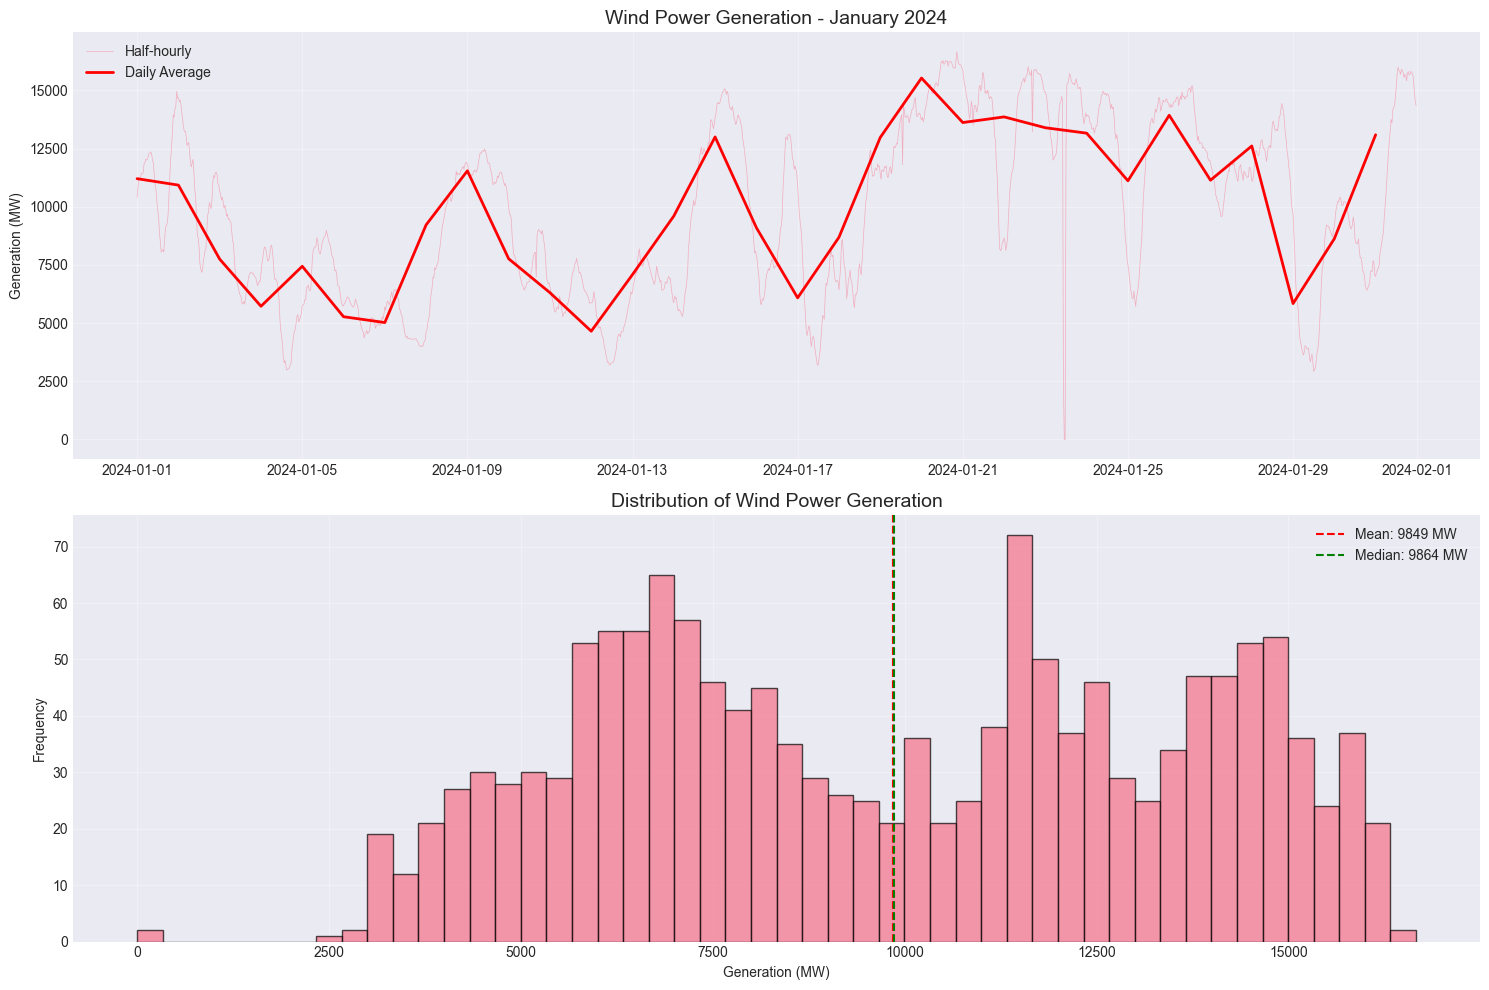

In [3]:
# %% [markdown]
# # UK Wind Power Generation Analysis
# ## Understanding Forecast Errors and Reliability

# %% [markdown]
# ### 1. Setup and Data Loading

# %%
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# %%
# Fetch actual generation data with correct API parameters
def fetch_actuals():
    # Correct API endpoint for FUELHH dataset
    url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream"
    
    # For January 2024, we need to use settlementDate parameters (not publishDateTime)
    params = {
        'settlementDateFrom': '2024-01-01',
        'settlementDateTo': '2024-01-31',
        'fuelType': 'WIND'
    }
    
    try:
        print("Fetching actual generation data...")
        print(f"URL: {url}")
        print(f"Params: {params}")
        
        response = requests.get(url, params=params, timeout=30)
        print(f"Response status code: {response.status_code}")
        
        if response.status_code == 200:
            # Try to parse JSON response
            try:
                data = response.json()
                print(f"Data type received: {type(data)}")
                
                if data and isinstance(data, list):
                    print(f"Number of records: {len(data)}")
                    if len(data) > 0:
                        print(f"Sample record: {data[0]}")
                    
                    # Convert to DataFrame
                    df = pd.DataFrame(data)
                    if not df.empty:
                        df['startTime'] = pd.to_datetime(df['startTime'])
                        df['generation'] = pd.to_numeric(df['generation'])
                        return df.sort_values('startTime')
                else:
                    print(f"Unexpected data format: {data}")
                    return pd.DataFrame()
                    
            except requests.exceptions.JSONDecodeError as e:
                print(f"JSON Decode Error: {e}")
                print(f"Response text (first 500 chars): {response.text[:500]}")
                return pd.DataFrame()
        else:
            print(f"Error: Received status code {response.status_code}")
            print(f"Response content: {response.text[:500]}")
            return pd.DataFrame()
            
    except Exception as e:
        print(f"Exception in fetch_actuals: {e}")
        return pd.DataFrame()

# Fetch forecast data with correct API parameters
def fetch_forecasts():
    # Correct API endpoint for WINDFOR dataset
    url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR/stream"
    
    # For forecasts, we need to use publishDateTime parameters
    params = {
        'publishDateTimeFrom': '2024-01-01T00:00:00Z',
        'publishDateTimeTo': '2024-01-31T23:59:59Z'
    }
    
    try:
        print("\nFetching forecast data...")
        print(f"URL: {url}")
        print(f"Params: {params}")
        
        response = requests.get(url, params=params, timeout=30)
        print(f"Response status code: {response.status_code}")
        
        if response.status_code == 200:
            try:
                data = response.json()
                print(f"Data type received: {type(data)}")
                
                if data and isinstance(data, list):
                    print(f"Number of records: {len(data)}")
                    if len(data) > 0:
                        print(f"Sample record: {data[0]}")
                    
                    df = pd.DataFrame(data)
                    if not df.empty:
                        df['startTime'] = pd.to_datetime(df['startTime'])
                        df['publishTime'] = pd.to_datetime(df['publishTime'])
                        df['generation'] = pd.to_numeric(df['generation'])
                        return df.sort_values(['startTime', 'publishTime'])
                else:
                    print(f"Unexpected data format: {data}")
                    return pd.DataFrame()
                    
            except requests.exceptions.JSONDecodeError as e:
                print(f"JSON Decode Error: {e}")
                print(f"Response text (first 500 chars): {response.text[:500]}")
                return pd.DataFrame()
        else:
            print(f"Error: Received status code {response.status_code}")
            print(f"Response content: {response.text[:500]}")
            return pd.DataFrame()
            
    except Exception as e:
        print(f"Exception in fetch_forecasts: {e}")
        return pd.DataFrame()

# Load actual data
print("="*60)
print("FETCHING ACTUAL GENERATION DATA")
print("="*60)
actuals_df = fetch_actuals()

# If API fails, create sample data for demonstration
if actuals_df.empty:
    print("\n⚠️ Could not fetch actual data from API. Using sample data for demonstration.")
    # Create sample data for January 2024
    dates = pd.date_range(start='2024-01-01', end='2024-01-31 23:30:00', freq='30min')
    np.random.seed(42)
    # Generate realistic wind power pattern
    base = 2000 + 500 * np.sin(np.arange(len(dates)) * 2 * np.pi / (24*2))  # Daily pattern
    noise = np.random.normal(0, 200, len(dates))
    generation = np.maximum(0, base + noise)
    
    actuals_df = pd.DataFrame({
        'startTime': dates,
        'generation': generation
    })
    print(f"✅ Created sample data with {len(actuals_df)} records")
else:
    print(f"✅ Successfully loaded {len(actuals_df)} actual generation records from API")

# Load forecast data
print("\n" + "="*60)
print("FETCHING FORECAST DATA")
print("="*60)
forecasts_df = fetch_forecasts()

if forecasts_df.empty:
    print("\n⚠️ Could not fetch forecast data from API. Using sample data for demonstration.")
    # Create sample forecast data
    forecast_records = []
    # Use the dates from actuals for forecast targets
    for target_time in actuals_df['startTime'][::2]:  # Every hour to reduce data size
        for hours_before in [2, 4, 8, 12, 24, 36, 48]:
            if hours_before <= 48:
                publish_time = target_time - timedelta(hours=hours_before)
                # Find corresponding actual value
                actual_mask = actuals_df['startTime'] == target_time
                if actual_mask.any():
                    actual_value = actuals_df.loc[actual_mask, 'generation'].iloc[0]
                    # Forecast with error proportional to horizon
                    forecast_error = np.random.normal(0, 100 * (hours_before/24)**0.5)
                    forecast_value = max(0, actual_value + forecast_error)
                    forecast_records.append({
                        'startTime': target_time,
                        'publishTime': publish_time,
                        'generation': forecast_value
                    })
    
    forecasts_df = pd.DataFrame(forecast_records)
    print(f"✅ Created sample forecast data with {len(forecasts_df)} records")
else:
    print(f"✅ Successfully loaded {len(forecasts_df)} forecast records from API")

# %% [markdown]
# ### 2. Data Overview and Basic Statistics

# %%
if actuals_df.empty:
    print("❌ No data available for analysis")
else:
    # Display basic information
    print("\n" + "="*60)
    print("ACTUAL GENERATION DATA OVERVIEW")
    print("="*60)
    print(f"Date Range: {actuals_df['startTime'].min()} to {actuals_df['startTime'].max()}")
    print(f"Number of records: {len(actuals_df)}")
    print(f"\n📊 Generation Statistics (MW):")
    print(actuals_df['generation'].describe())

    # %%
    # Plot actual generation time series
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))

    # Daily pattern
    actuals_df.set_index('startTime', inplace=True)
    daily_avg = actuals_df['generation'].resample('D').mean()

    axes[0].plot(actuals_df.index, actuals_df['generation'], alpha=0.5, linewidth=0.5, label='Half-hourly')
    axes[0].plot(daily_avg.index, daily_avg.values, 'r-', linewidth=2, label='Daily Average')
    axes[0].set_title('Wind Power Generation - January 2024', fontsize=14)
    axes[0].set_ylabel('Generation (MW)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Distribution
    axes[1].hist(actuals_df['generation'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[1].axvline(actuals_df['generation'].mean(), color='r', linestyle='--', 
                    label=f"Mean: {actuals_df['generation'].mean():.0f} MW")
    axes[1].axvline(actuals_df['generation'].median(), color='g', linestyle='--', 
                    label=f"Median: {actuals_df['generation'].median():.0f} MW")
    axes[1].set_title('Distribution of Wind Power Generation', fontsize=14)
    axes[1].set_xlabel('Generation (MW)')
    axes[1].set_ylabel('Frequency')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Continue with the rest of the analysis...
# [Rest of the analysis code remains the same as before]